# Exercise 3: Fitting

## Analysis of Exponential Decay Data

You are given a dataset representing exponential decay with added noise. The fraction of remaining particles follows the equation:  


$$y = e^{t/\tau}$$


where:  
- $ \tau $ is the decay constant,  
- $ t $ represents time,  
- measurement uncertainty is estimated to be $ \sigma = 0.1 $ for all times.  

**Tasks**  

**1. Compute the Chi-Squared Statistic**  
- Evaluate $ \chi^2 $ for $ \tau $ values between 1 and 2.  
- Identify the best-fit $ \tau $ by finding the minimum $ \chi^2 $.  

**2. Estimate Uncertainty**  
- Use the $ \Delta \chi^2 $ method to determine the confidence interval for $ \tau $.  

**3. Visualize the Data and Best Fit**  
- Plot the given data with error bars.  
- Overlay the best-fit exponential decay curve.  

**4. Graphical Representation of $ \chi^2 $**  
- Plot $ \chi^2 $ as a function of $ \tau $.  
- Highlight the $ 1\sigma $ confidence regions based on $ \Delta \chi^2 $.  

**5. Goodness of fit**
- Looking at the mimimum $\chi^2$, do you think the uncertainty estimation is realistic?

In [2]:
import numpy as np
t, data = np.loadtxt("data_ex1.txt", unpack=True) #here data refers to the fraction of remaining particles (according to the description of the exercise)
data_errors = np.full_like(data, 0.1)
data_var = data_errors ** 2

In the lecture, we learned how to compute the best estimate of a parameter analytically in the case of a linear function. Now, compute the best estimate for $\tau$, including the uncertainty, in a similar way. 

Do you get "compatible" results ?

**Hint**: You may want to use a coordinate transformation.

In [3]:
# 1.
def compute_chisquared(x,y,var_y,model,**dict_args):
    """Computes the chi-squared of the set of data
    
    The function needs the data as inputs, the variance of the y data and the function of the distribution to
    which the data belongs. It returns the not-normalized chi-squared. Additionally you can give more inputs:
    - model_param: the collection of parameters needed by the function  model, passed as an iterable object if
                   the model needs more than one parameter
    - var_x:       the variance of the x coordinates"""
    import numpy as np

    # Checking basic input sizes
    if (len(x) != len(y)) or (len(x) != len(var_y)):
        print("Inputs to compute_chisquared have different lengths. Aborting")
        raise ValueError("Stopping execution due to invalid input size.")
    N = len(x)

    # Managing variances
    var = np.zeros(N)
    i = 0
    try: #try if there are variances of the x coordinates
        if len(x) != len(dict_args['var_x']):
            print("Inputs to compute_chisquared have different lengths. Aborting")
            raise ValueError("Stopping execution due to invalid input size.")
        from scipy.optimize import approx_fprime
        try: #try with parameters for the model
            while i < N:
                var[i] = dict_args['var_x'][i]*(approx_fprime(x[i],model,1e-8,dict_args['model_param'])[0])**2 + var_y[i] #note that approx_fprime returns an array: in our case it is simply made of a single number, so I select the first and only entry to avoid errors
                i += 1
        except KeyError: #no parameters for the model
            try: #try without parameters for the model
                while i < N:
                    var[i] = dict_args['var_x'][i]*(approx_fprime(x[i],model,1e-8)[0])**2 + var_y[i] #note that approx_fprime returns an array: in our case it is simply made of a single number, so I select the first and only entry to avoid errors
                    i += 1
            except IndexError: #no parameters but the model needs them
                print("compute_chisquared: no model_parameter detected but the model requires them. Aborting")
                raise
        except TypeError: #the model doesn't want additional parameters
            print("compute_chisquared: model_parameter detected but the model doesn't require them. Aborting")
            raise
        #print("compute_chisquared: var_x detected!")
    except KeyError: #no variances of the x coordinates
        while i < N:
            var[i] = var_y[i]
            i += 1
        #print("compute_chisquared: no var_x detected!")

    # Computing chi-squared
    chi_squared = 0
    i = 0
    try: #try with parameters for the model
        while i < N:
            chi_squared += (model(x[i],dict_args['model_param']) - y[i])**2/var[i]
            i += 1
        #print("compute_chisquared: model_param detected!")
    except KeyError: #no parameters for the model
        try: #try without parameters for the model
            while i < N:
                chi_squared += (model(x[i]) - y[i])**2/var[i]
                i += 1
        except IndexError: #no parameters but the model needs them
            print("compute_chisquared: no model_parameter detected but the model requires them. Aborting")
            raise
        #print("compute_chisquared: no model_param detected!")
    except TypeError: #the model doesn't want additional parameters
            print("compute_chisquared: model_parameter detected but the model doesn't require them. Aborting")
            raise

    # Returning the final outcome
    return chi_squared
    

In [4]:
def exp_decay(t,*tau):
    import math as m

    try:
        tau[1]
        print("exp_decay: too many input parameters. Aborting")
        raise ValueError("Stopping execution due to an excess number of parameters.")
    except IndexError:
        try:
            tau[0][1] #tau is a tuple of given inputs. When compute_chisquared calls this function, the parameters are stored in the first
                      #entry of the tuple. In this case it's only a single number, in case of multiple parameters, the first entry is a
                      #tuple or a list itself
            print("exp_decay: too many input parameters. Aborting")
            raise ValueError("Stopping execution due to an excess number of parameters.")
        except IndexError:
            return m.exp(-t/tau[0]) #taking the first and only entry
        except TypeError:
            return m.exp(-t/tau[0]) #taking the first and only entry

In [5]:
import numpy as np

tau_values = np.linspace(0.1,20,int(1e4))
chi_squared_values = []
for tau in tau_values:
    chi_squared_values.append(compute_chisquared(t, data, data_var, exp_decay, model_param=tau))
chi_squared_values = np.array(chi_squared_values)

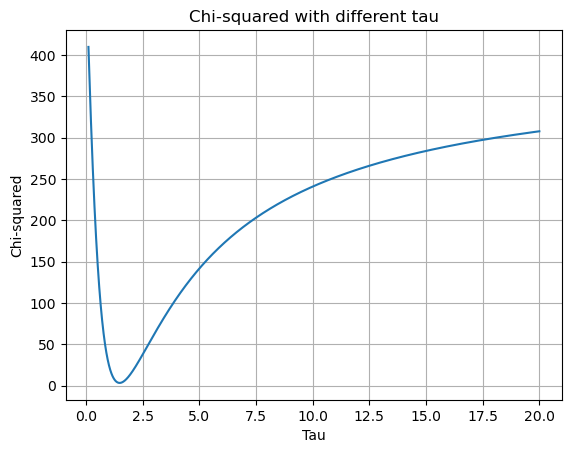

In [6]:
import matplotlib.pyplot as plt

plt.plot(tau_values, chi_squared_values)
plt.grid(1)
plt.title('Chi-squared with different tau')
plt.xlabel('Tau')
plt.ylabel('Chi-squared')
plt.show()

In [7]:
# Since we can see from the graph that there's a minimum between 0.5 and 2.5, I'll look for it there
tau_values = np.linspace(0.5,2.5,int(1e5))
chi_squared_values = []
for tau in tau_values:
    chi_squared_values.append(compute_chisquared(t, data, data_var, exp_decay, model_param=tau))
chi_squared_values = np.array(chi_squared_values)

index = np.argmin(chi_squared_values)
best_tau = tau_values[index]
print(f"The optimal value for tau is {best_tau}, corresponding to a chi value of {chi_squared_values[index]}")

The optimal value for tau is 1.476029760297603, corresponding to a chi value of 3.422776975486686


In [8]:
# 2.
# Not taught in the lesson yet

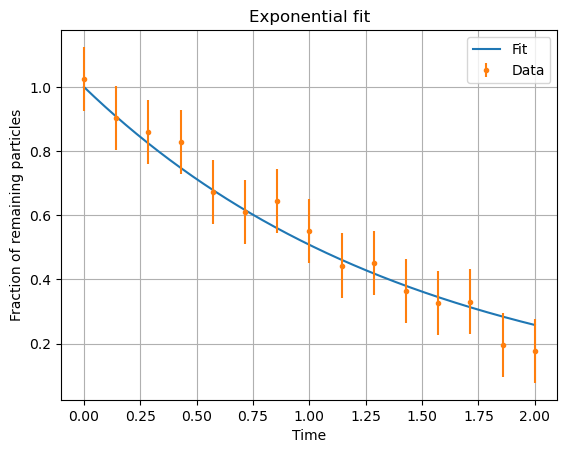

In [9]:
# 3.
import matplotlib.pyplot as plt

x = np.linspace(min(t),max(t),int(1e4))
y = []
for point in x:
    y.append(exp_decay(point,best_tau))
y = np.array(y)

plt.plot(x,y,label='Fit')
plt.errorbar(t,data,data_errors, fmt='.', label='Data')
plt.grid(1)
plt.legend()
plt.title('Exponential fit')
plt.xlabel('Time')
plt.ylabel('Fraction of remaining particles')
plt.show()

In [10]:
# 4.
# Not explained yet

In [11]:
# 5.
# The value of the minimum reduced chi-squared is
chi_squared_values[index]/(len(t)-1)
# which is quite below one. The p-value corresponding to this chi-squared is
from scipy.stats import chi2
1-chi2.cdf(chi_squared_values[index],len(t)-1)
#which is super high

np.float64(0.9980541645972586)

In [23]:
# 6.
# We can rewrite log(data) = -t/tau and estimate tau as the opposite of the inverse of the coefficient of a linear fit between t
# (as x coordinates) and log(data) (as y coordinates). Also, the straight line shall pass through the origin.
m = np.average(t*np.log(data)) / np.average(t**2)
var_m = data_var[0]/len(t)/np.average(t**2)

analytical_best_tau = -1/m
var_analytical_best_tau = 1/m**4*var_m
print(f"Analytical value for the best tau: {analytical_best_tau}+/-{np.sqrt(var_analytical_best_tau)}")
# I am still missing the uncertainty on tau estimated by minimizing the chi-squared.

Analytical value for the best tau: 1.358709810389081+/-0.040561914124827944


## Polynomial Fit with Parameter Uncertainty

You are given data that was generated using a polynomial of degree 5. Therefore, you have 6 free parameters (the 6 coefficients). Your task is to perform a fit to obtain these parameters and their covariances.

**Steps:**
1. Fit a polynomial to the data and determine the parameters.
2. Calculate the uncertainties for each parameter.
3. **Bonus**: Instead of just showing the 1D uncertainties for each parameter, visualize the correlations between these uncertainties.

You can use an optimizer from `scipy` to perform the fit and "TriangleChain" for the last point.

In [6]:
x, data = np.loadtxt("data_ex2.txt", unpack=True)

In [1]:
!pip install trianglechain

## Goodness of fit

You are given datasets $x$ and $y$ that follow a polynomial relationship, with the uncertainty in $y$ equal to 5. Fit both a first-degree (linear) and a second-degree (quadratic) polynomial to the data. Compute the reduced chi-squared and the p-value for each model. Determine which model provides a better fit based on these statistical measures.

What would happen to the p value if you further increase the degrees of the polynomial?

In [9]:
x, y = np.loadtxt("data_ex3.txt", unpack=True)
y_err = np.ones_like(y) * 5

## Gradient descent
Minimize the function:

$$
f(x, y) = x^2 + (y - 1)^2 + 0.1 \cdot x^4 + 0.1 \cdot y^4
$$

1. **Compute the Gradient**  
   Find the partial derivatives of the function with respect to $x$ and $y$.

2. **Implement Gradient Descent**  
   Update the parameters using:
   $$
   x_{\text{new}} = x_{\text{old}} - \alpha \cdot \frac{\partial f}{\partial x}, \quad y_{\text{new}} = y_{\text{old}} - \alpha \cdot \frac{\partial f}{\partial y}
   $$

3. **Plot the Path to the Minimum**  
   Run gradient descent with different starting points and learning rates. Plot the optimization path to the minimum for the different scenarios and plot how the step size evolves.

4. **Different function**
    Change the initial function (e.g. change $x^2$ to $x^3$) and redo Steps 1-3. Do you have to adapt the learning rate?